In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load the dataset
file_path = "C:/Users/meets/Music/Infosys Opti-Price/final_data.csv"
df = pd.read_csv(file_path)

In [3]:
# Display basic information about the dataset
df_info = df.info()
df_head = df.head()
df_description = df.describe()

df_info, df_head, df_description

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        50000 non-null  int64  
 1   email                              50000 non-null  object 
 2   phone_number                       50000 non-null  object 
 3   Date_of_Journey                    50000 non-null  object 
 4   departure_time                     50000 non-null  object 
 5   arrival_time                       50000 non-null  object 
 6   Departure                          50000 non-null  object 
 7   Destination                        50000 non-null  object 
 8   departure_airport                  50000 non-null  object 
 9   arrival_airport                    50000 non-null  object 
 10  hotel_check_in_date                50000 non-null  object 
 11  hotel_check_out_date               50000 non-null  obj

(None,
    customer_id                   email phone_number Date_of_Journey  \
 0       636354  user636354@example.com  +1-364-7883      2024-02-11   
 1       508907  user508907@example.com  +1-739-8336      2024-11-08   
 2       345754  user345754@example.com  +1-499-2619      2024-07-09   
 3       628555  user628555@example.com  +1-406-1626      2024-06-08   
 4       687849  user687849@example.com  +1-202-9294      2024-06-13   
 
   departure_time arrival_time    Departure Destination departure_airport  \
 0        7:10 PM     12:35 PM      Houston    New York               IAH   
 1        5:20 PM      3:04 AM  Los Angeles     Chicago               LAX   
 2        9:51 PM      4:14 AM        Miami     Houston               MIA   
 3       10:08 PM      8:18 AM        Dubai      Sydney               DXB   
 4        1:04 PM      1:00 AM      Chicago       Paris               ORD   
 
   arrival_airport  ... age  gender booking_source  special_requests  \
 0             JFK  ...

In [4]:
# Convert date columns to datetime format
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'])
df['hotel_check_in_date'] = pd.to_datetime(df['hotel_check_in_date'])
df['hotel_check_out_date'] = pd.to_datetime(df['hotel_check_out_date'])

# Convert time columns to datetime format (time only)
df['departure_time'] = pd.to_datetime(df['departure_time'], format='%I:%M %p').dt.time
df['arrival_time'] = pd.to_datetime(df['arrival_time'], format='%I:%M %p').dt.time

# Extract additional features from Date_of_Journey
df['journey_day'] = df['Date_of_Journey'].dt.day
df['journey_month'] = df['Date_of_Journey'].dt.month
df['journey_weekday'] = df['Date_of_Journey'].dt.weekday  # 0=Monday, 6=Sunday

# Check cleaned data types and display first few rows
df.dtypes, df.head()

(customer_id                                   int64
 email                                        object
 phone_number                                 object
 Date_of_Journey                      datetime64[ns]
 departure_time                               object
 arrival_time                                 object
 Departure                                    object
 Destination                                  object
 departure_airport                            object
 arrival_airport                              object
 hotel_check_in_date                  datetime64[ns]
 hotel_check_out_date                 datetime64[ns]
 hotel_country                                object
 ticket_price                                float64
 hotel_price                                 float64
 total_spent                                 float64
 flight_class                                 object
 room_type                                    object
 payment_method                               

C:\Users\meets\AppData\Local\Temp\ipykernel_9180\533734402.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='journey_month', data=df, palette="viridis", ax=axes[1, 0])
C:\Users\meets\AppData\Local\Temp\ipykernel_9180\533734402.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='season', y='ticket_price', data=df, palette="coolwarm", ax=axes[1, 1])


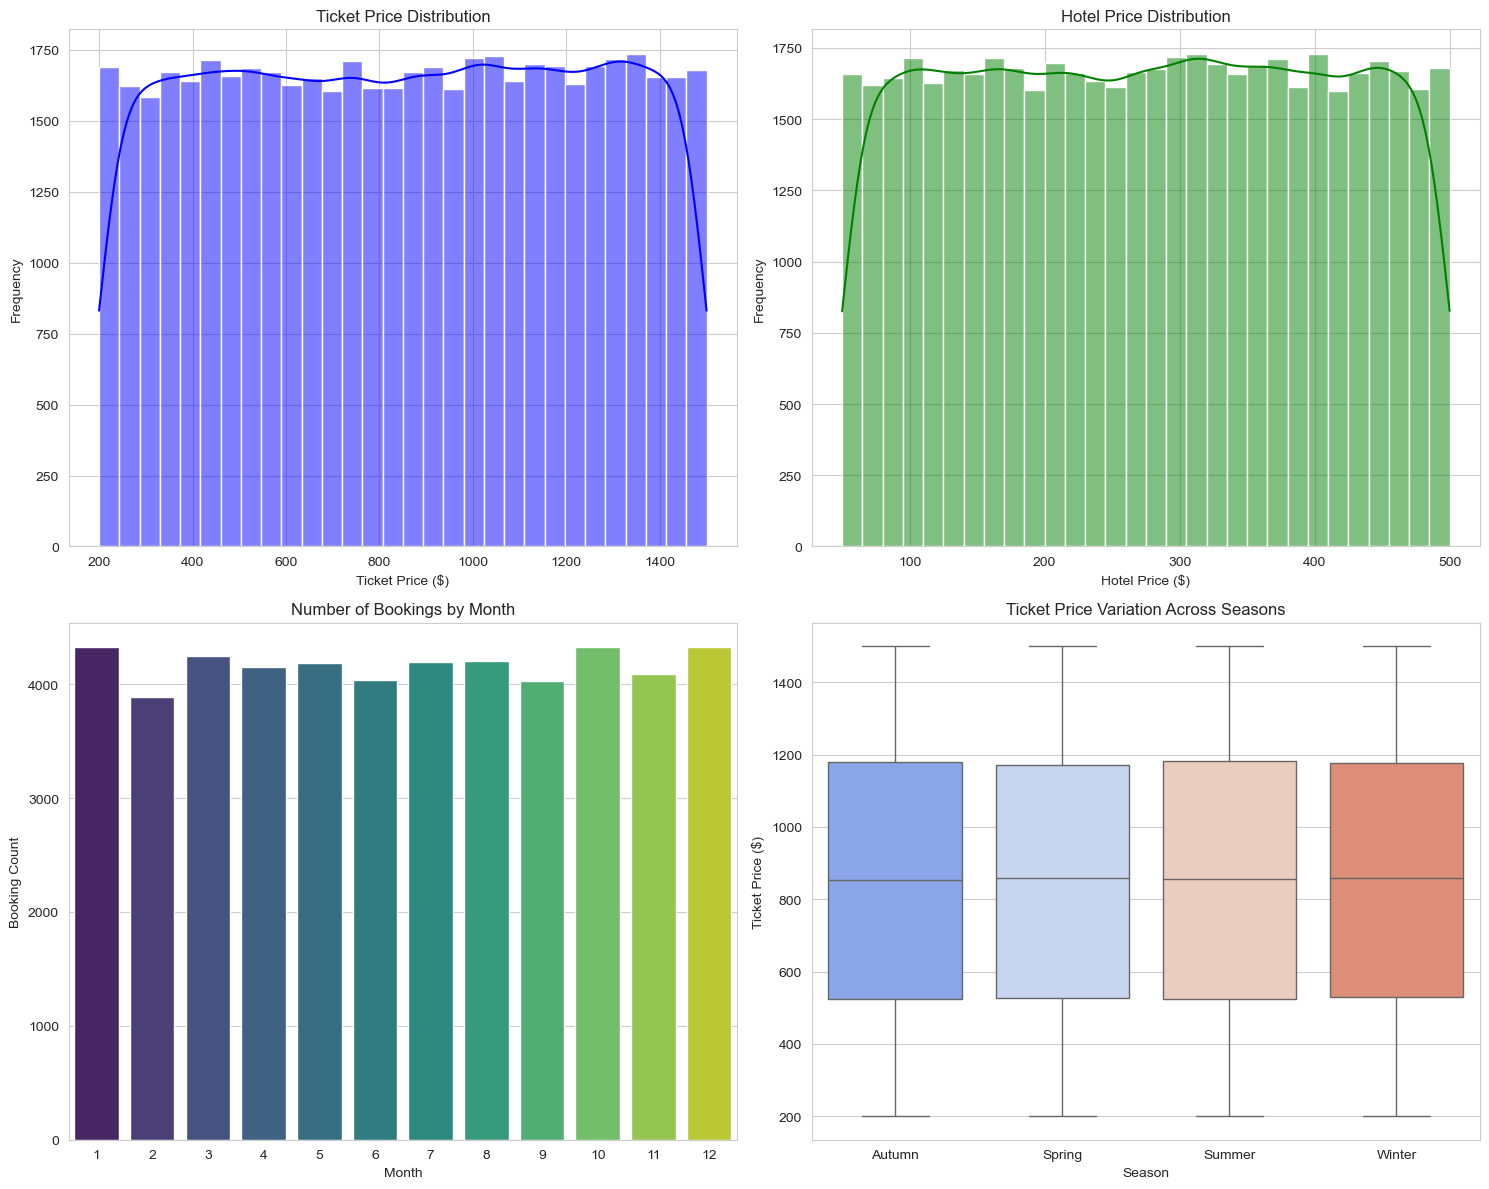

In [5]:
# Set the style
sns.set_style("whitegrid")

# Figure setup
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Ticket Price Distribution
sns.histplot(df['ticket_price'], bins=30, kde=True, ax=axes[0, 0], color="blue")
axes[0, 0].set_title("Ticket Price Distribution")
axes[0, 0].set_xlabel("Ticket Price ($)")
axes[0, 0].set_ylabel("Frequency")

# 2. Hotel Price Distribution
sns.histplot(df['hotel_price'], bins=30, kde=True, ax=axes[0, 1], color="green")
axes[0, 1].set_title("Hotel Price Distribution")
axes[0, 1].set_xlabel("Hotel Price ($)")
axes[0, 1].set_ylabel("Frequency")

# 3. Booking Trends by Month
sns.countplot(x='journey_month', data=df, palette="viridis", ax=axes[1, 0])
axes[1, 0].set_title("Number of Bookings by Month")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Booking Count")

# 4. Seasonal Impact on Ticket Prices
sns.boxplot(x='season', y='ticket_price', data=df, palette="coolwarm", ax=axes[1, 1])
axes[1, 1].set_title("Ticket Price Variation Across Seasons")
axes[1, 1].set_xlabel("Season")
axes[1, 1].set_ylabel("Ticket Price ($)")

# Adjust layout
plt.tight_layout()
plt.show()

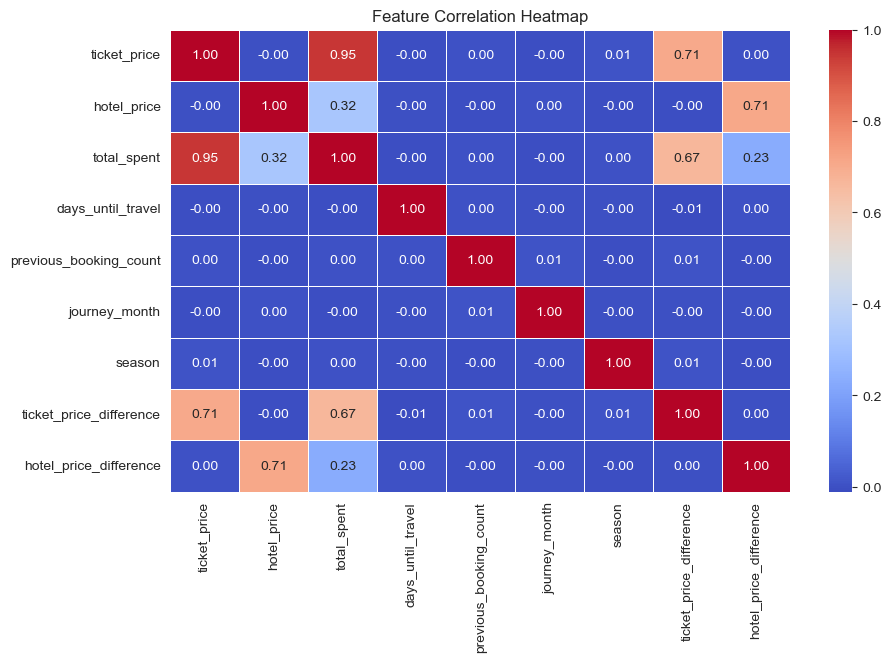

In [6]:
# Encode categorical variables using Label Encoding
categorical_columns = ['flight_class', 'room_type', 'payment_method', 'gender', 
                       'booking_source', 'season', 'dynamic_pricing_suggestion']

label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store encoders for inverse transformation if needed

# Create demand-based features
df['ticket_price_difference'] = df['ticket_price'] - df['average_ticket_price_last_30_days']
df['hotel_price_difference'] = df['hotel_price'] - df['average_hotel_price_last_30_days']

# Correlation Analysis
correlation_matrix = df[['ticket_price', 'hotel_price', 'total_spent', 'days_until_travel',
                         'previous_booking_count', 'journey_month', 'season', 
                         'ticket_price_difference', 'hotel_price_difference']].corr()

# Display correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [7]:
# Step 2: Feature Engineering
def preprocess_data(df):
    # Convert date columns to datetime format
    df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'])
    df['hotel_check_in_date'] = pd.to_datetime(df['hotel_check_in_date'])
    df['hotel_check_out_date'] = pd.to_datetime(df['hotel_check_out_date'])
    
    # Extract features from Date_of_Journey
    df['journey_day'] = df['Date_of_Journey'].dt.day
    df['journey_month'] = df['Date_of_Journey'].dt.month
    df['journey_weekday'] = df['Date_of_Journey'].dt.weekday
    
    # Create demand-based features
    df['ticket_price_difference'] = df['ticket_price'] - df['average_ticket_price_last_30_days']
    df['hotel_price_difference'] = df['hotel_price'] - df['average_hotel_price_last_30_days']
    df['price_elasticity'] = df['ticket_price'] / (df['ticket_price_difference'] + 1e-6)
    df['peak_season'] = df['season'].apply(lambda x: 1 if x in ['Summer', 'Autumn'] else 0)
    
    # Apply Target Encoding
    from category_encoders import TargetEncoder
    target_enc = TargetEncoder(cols=['booking_source', 'payment_method', 'flight_class'])
    df[['booking_source', 'payment_method', 'flight_class']] = target_enc.fit_transform(df[['booking_source', 'payment_method', 'flight_class']], df['ticket_price'])
    
    return df, target_enc

In [17]:
# Step 3: Train-Test Split & Scaling
def split_and_scale_data(df, target='ticket_price'):
    features = ['days_until_travel', 'previous_booking_count', 'journey_month', 'season', 
                'ticket_price_difference', 'hotel_price_difference', 'price_elasticity', 'peak_season',
                'flight_class', 'room_type', 'payment_method', 'gender', 'booking_source']
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42)
    
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    numerical_features = ['ticket_price_difference', 'hotel_price_difference', 'days_until_travel', 'previous_booking_count', 'price_elasticity']
    X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
    X_test[numerical_features] = scaler.transform(X_test[numerical_features])
    
    return X_train, X_test, y_train, y_test, scaler

In [21]:
# Step 4: Model Training (XGBoost, LightGBM, CatBoost)
def train_models(X_train, y_train):
    models = {}
    
    # Train XGBoost
    import xgboost as xgb
    xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, objective='reg:squarederror', random_state=42)
    xgb_model.fit(X_train, y_train)
    models['XGBoost'] = xgb_model
    
    # Train LightGBM
    import lightgbm as lgb
    lgb_model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42)
    lgb_model.fit(X_train, y_train)
    models['LightGBM'] = lgb_model
    
    # Train CatBoost
    import catboost as cb
    cb_model = cb.CatBoostRegressor(iterations=200, learning_rate=0.05, depth=6, random_state=42, verbose=0)
    cb_model.fit(X_train, y_train)
    models['CatBoost'] = cb_model
    
    return models

In [23]:
!pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable


In [24]:
!pip install catboost

Defaulting to user installation because normal site-packages is not writeable


In [25]:
# Step 5: Model Evaluation
def evaluate_models(models, X_test, y_test):
    from sklearn.metrics import mean_squared_error, r2_score
    results = {}
    for name, model in models.items():
        y_pred = model.predict(X_test)
        rmse = mean_squared_error(y_test, y_pred, squared=False)
        r2 = r2_score(y_test, y_pred)
        results[name] = {'RMSE': rmse, 'R2': r2}
    return results

# Run Training & Evaluation
print("Training Models...")
models = train_models(X_train, y_train)

print("Evaluating Models...")
results = evaluate_models(models, X_test, y_test)
print(results)

Training Models...


NameError: name 'X_train' is not defined

In [27]:
!pip install optuna catboost

Defaulting to user installation because normal site-packages is not writeable


In [28]:
!pip install category_encoders

Defaulting to user installation because normal site-packages is not writeable


In [29]:
!pip install --upgrade category_encoders scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [30]:
import pandas as pd
import numpy as np
import optuna
import catboost as cb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from category_encoders import TargetEncoder

In [35]:
# Load Dataset
df = pd.read_csv("final_data.csv")

# Convert date columns to datetime format
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'])
df['hotel_check_in_date'] = pd.to_datetime(df['hotel_check_in_date'])
df['hotel_check_out_date'] = pd.to_datetime(df['hotel_check_out_date'])

# Extract date-based features
df['journey_day'] = df['Date_of_Journey'].dt.day
df['journey_month'] = df['Date_of_Journey'].dt.month
df['journey_weekday'] = df['Date_of_Journey'].dt.weekday

# Create demand-based features
df['ticket_price_difference'] = df['ticket_price'] - df['average_ticket_price_last_30_days']
df['hotel_price_difference'] = df['hotel_price'] - df['average_hotel_price_last_30_days']
df['price_elasticity'] = df['ticket_price'] / (df['ticket_price_difference'] + 1e-6)
df['peak_season'] = df['season'].apply(lambda x: 1 if x in ['Summer', 'Autumn'] else 0)

# Target Encoding for categorical variables
target_enc = TargetEncoder(cols=['booking_source', 'payment_method', 'flight_class'])
df[['booking_source', 'payment_method', 'flight_class']] = target_enc.fit_transform(df[['booking_source', 'payment_method', 'flight_class']], df['ticket_price'])

In [37]:
# Define features and target variable
features = ['days_until_travel', 'previous_booking_count', 'journey_month', 'season', 
            'ticket_price_difference', 'hotel_price_difference', 'price_elasticity', 'peak_season',
            'flight_class', 'room_type', 'payment_method', 'gender', 'booking_source']
target = 'ticket_price'

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42)

# Standardizing numerical features
scaler = StandardScaler()
numerical_features = ['ticket_price_difference', 'hotel_price_difference', 'days_until_travel', 'previous_booking_count', 'price_elasticity']
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

In [45]:
from sklearn.metrics import mean_squared_error
import numpy as np

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'random_seed': 42,
        'verbose': 0
    }
    
    model = cb.CatBoostRegressor(**params, cat_features=cat_features)
    model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50, verbose=0)
    y_pred = model.predict(X_test)
    
    # Compute RMSE manually
    return np.sqrt(mean_squared_error(y_test, y_pred))

In [53]:
print("Number of completed trials:", len(study.trials))

Number of completed trials: 1


In [55]:
for trial in study.trials:
    print(f"Trial {trial.number} - Status: {trial.state}")

Trial 0 - Status: 3


In [57]:
print(study.trials[0])

FrozenTrial(number=0, state=3, values=None, datetime_start=datetime.datetime(2025, 3, 3, 22, 25, 4, 248851), datetime_complete=datetime.datetime(2025, 3, 3, 22, 25, 48, 910238), params={'iterations': 457, 'learning_rate': 0.07705049319608857, 'depth': 7, 'l2_leaf_reg': 5.481895479645975, 'subsample': 0.8543386624109122}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'iterations': IntDistribution(high=500, log=False, low=100, step=1), 'learning_rate': FloatDistribution(high=0.3, log=False, low=0.01, step=None), 'depth': IntDistribution(high=10, log=False, low=4, step=1), 'l2_leaf_reg': FloatDistribution(high=10.0, log=False, low=1.0, step=None), 'subsample': FloatDistribution(high=1.0, log=False, low=0.5, step=None)}, trial_id=0, value=None)


In [59]:
cat_features = ['season', 'flight_class', 'room_type', 'payment_method', 'gender', 'booking_source']
X_train[cat_features] = X_train[cat_features].astype(str)
X_test[cat_features] = X_test[cat_features].astype(str)

In [61]:
import traceback

def objective(trial):
    try:
        params = {
            'iterations': trial.suggest_int('iterations', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'random_seed': 42,
            'verbose': 0
        }

        model = cb.CatBoostRegressor(**params, cat_features=cat_features)
        model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50, verbose=0)
        y_pred = model.predict(X_test)

        # Compute RMSE manually
        return np.sqrt(mean_squared_error(y_test, y_pred))

    except Exception as e:
        print(f"Trial {trial.number} failed: {e}")
        traceback.print_exc()  # Print the full error traceback
        return float('inf')  # Return a large RMSE to indicate failure


In [63]:
study.optimize(objective, n_trials=20)

[I 2025-03-03 22:31:57,610] Trial 1 finished with value: 77.80402396984826 and parameters: {'iterations': 100, 'learning_rate': 0.18133606094580793, 'depth': 4, 'l2_leaf_reg': 9.07983132877916, 'subsample': 0.7998864947865836}. Best is trial 1 with value: 77.80402396984826.
[I 2025-03-03 22:32:07,102] Trial 2 finished with value: 51.82252504526348 and parameters: {'iterations': 120, 'learning_rate': 0.28604383266692773, 'depth': 6, 'l2_leaf_reg': 9.03653606867427, 'subsample': 0.8899244338871226}. Best is trial 2 with value: 51.82252504526348.
[I 2025-03-03 22:33:46,101] Trial 3 finished with value: 45.78657243875097 and parameters: {'iterations': 445, 'learning_rate': 0.12828634318605692, 'depth': 10, 'l2_leaf_reg': 5.511208579869612, 'subsample': 0.8224307492112928}. Best is trial 3 with value: 45.78657243875097.
[I 2025-03-03 22:34:01,301] Trial 4 finished with value: 47.83964648597966 and parameters: {'iterations': 162, 'learning_rate': 0.2803689037131629, 'depth': 7, 'l2_leaf_reg'

In [67]:
best_params = study.best_trial.params
print("Best Parameters:", best_params)

Best Parameters: {'iterations': 447, 'learning_rate': 0.250814738413167, 'depth': 8, 'l2_leaf_reg': 5.952816903885219, 'subsample': 0.8102389958538018}


In [71]:
# Define categorical features
cat_features = ['season', 'flight_class', 'room_type', 'payment_method', 'gender', 'booking_source']

# Convert categorical features to strings
X_train[cat_features] = X_train[cat_features].astype(str)
X_test[cat_features] = X_test[cat_features].astype(str)

# Train the final model
best_model = cb.CatBoostRegressor(**best_params, cat_features=cat_features, random_seed=42, verbose=0)
best_model.fit(X_train, y_train)

In [73]:
y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Final Optimized CatBoost RMSE: {rmse:.4f}")
print(f"Final Optimized CatBoost R²: {r2:.4f}")

Final Optimized CatBoost RMSE: 45.9743
Final Optimized CatBoost R²: 0.9850


In [75]:
best_model.save_model("optimized_catboost_model.cbm")

In [77]:
loaded_model = cb.CatBoostRegressor()
loaded_model.load_model("optimized_catboost_model.cbm")

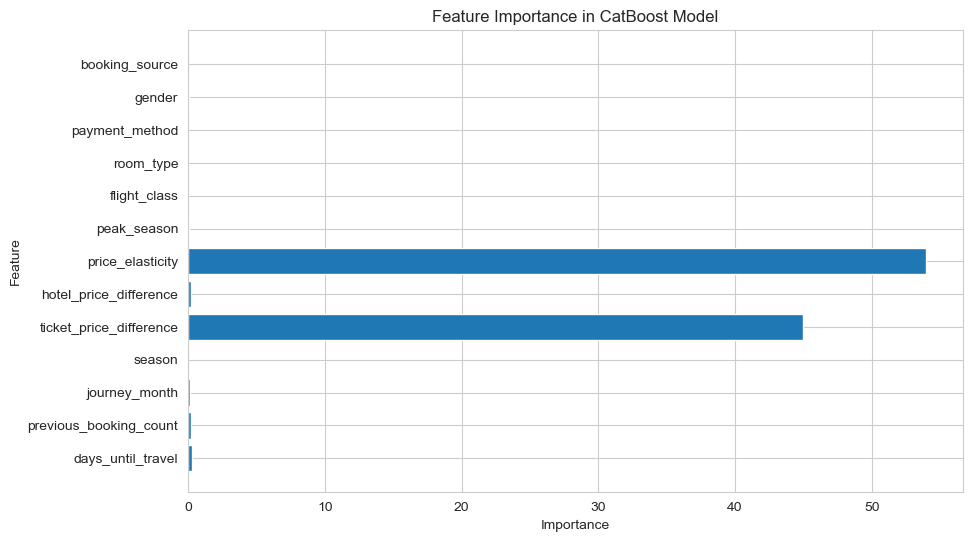

In [79]:
import matplotlib.pyplot as plt

feature_importance = best_model.get_feature_importance()
feature_names = X_train.columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importance)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance in CatBoost Model")
plt.show()

In [81]:
new_data = X_test.iloc[:5]  # Example: first 5 test samples
predicted_prices = best_model.predict(new_data)
print("Predicted Prices:", predicted_prices)

Predicted Prices: [ 228.83725532 1094.57021338 1233.48575946 1406.3839505  1041.63157231]


In [83]:
best_model.save_model("optimized_catboost_model.cbm")

In [85]:
loaded_model = cb.CatBoostRegressor()
loaded_model.load_model("optimized_catboost_model.cbm")

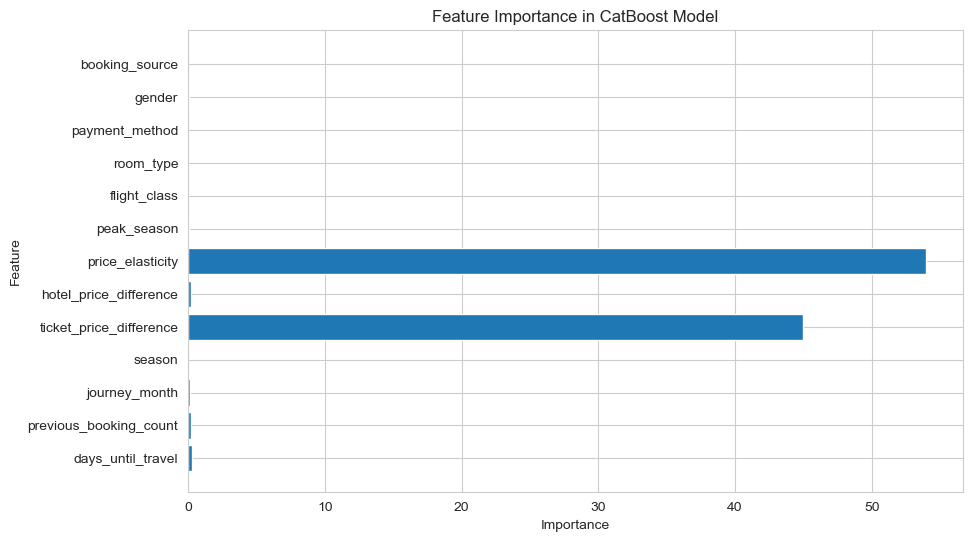

In [87]:
import matplotlib.pyplot as plt

feature_importance = best_model.get_feature_importance()
feature_names = X_train.columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importance)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance in CatBoost Model")
plt.show()

In [89]:
new_data = pd.DataFrame({
    "days_until_travel": [30],
    "previous_booking_count": [5],
    "journey_month": [6],
    "season": ["Summer"],
    "ticket_price_difference": [50.0],
    "hotel_price_difference": [30.0],
    "price_elasticity": [1.2],
    "peak_season": [1],
    "flight_class": ["Economy"],
    "room_type": ["Deluxe"],
    "payment_method": ["Credit Card"],
    "gender": ["Male"],
    "booking_source": ["Website"]
})

# Convert categorical features to string
new_data[cat_features] = new_data[cat_features].astype(str)

# Predict Price
predicted_price = best_model.predict(new_data)
print("Predicted Dynamic Price:", predicted_price)

Predicted Dynamic Price: [1357.28885679]


In [91]:
best_model.save_model("optimized_catboost_model.cbm")
print("Model saved successfully!")

Model saved successfully!


In [93]:
!pip install flask

Defaulting to user installation because normal site-packages is not writeable
